In [26]:
from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import RepeatedKFold, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import optuna
import matplotlib.pyplot as plt

In [16]:
df1 = pd.read_csv('cleaned_with_text.csv')
df2 = pd.read_csv('cleaned_without.csv')
train_ratio = 0.70
test_ratio = 0.15
validation_ratio = 0.15

In [17]:
X = df1[['sqft','stories','beds','baths','baths_full','baths_full_calc','garage','year_built','type_condos','type_farm','type_multi_family','type_single_family','type_townhome']]
y = df1['listPrice']
text = df1["text"].fillna("")

X_num_train, X_num_temp, text_train, text_temp, y_train, y_temp = train_test_split(
    X, text, y, test_size=0.3, random_state=42
)

X_num_val, X_num_test, text_val, text_test, y_val, y_test = train_test_split(
    X_num_temp, text_temp, y_temp, test_size=0.5, random_state=42
)

In [18]:
pipeline = Pipeline([
                    ('imputer',SimpleImputer(strategy='mean')),
                    ('regressor', Ridge(alpha=1.0))
                    ])

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_text_train = tfidf.fit_transform(text_train)
X_text_val = tfidf.transform(text_val)
X_text_test = tfidf.transform(text_test)

X_train = hstack([X_text_train, X_num_train.values])
X_val = hstack([X_text_val, X_num_val.values])
X_test = hstack([X_text_test, X_num_test.values])

In [19]:
pipeline.fit(X_train,y_train)
y_pred_test = pipeline.predict(X_test)
y_pred_val  = pipeline.predict(X_val)
y_pred_train = pipeline.predict(X_train)

val_pred_default = pipeline.predict(X_val)
test_pred_default = pipeline.predict(X_test)

print("── Default ──")
print("Val R²:  ", round(r2_score(y_val, val_pred_default), 4))
print("Val RMSE:", round(np.sqrt(mean_squared_error(y_val, val_pred_default)), 4))
print("Val MAE: ", round(mean_absolute_error(y_val, val_pred_default), 4))
print("Test R²:  ", round(r2_score(y_test, test_pred_default), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, test_pred_default)), 4))
print("Test MAE: ", round(mean_absolute_error(y_test, test_pred_default), 4))

── Default ──
Val R²:   0.508
Val RMSE: 0.4302
Val MAE:  0.2985
Test R²:   0.329
Test RMSE: 0.5299
Test MAE:  0.3197


In [35]:
def objective(trial):
    # Ridge parameter
    alpha = trial.suggest_float('alpha', 1e-3, 100, log=True)
    
    # TF-IDF parameters
    max_features = trial.suggest_int('max_features', 1000, 10000, step=1000)
    ngram_max    = trial.suggest_int('ngram_max', 1, 3)  # 1=(1,1), 2=(1,2), 3=(1,3)

    # Fit TF-IDF on train only
    tfidf = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, ngram_max),
        stop_words='english'
    )
    X_text_train_t = tfidf.fit_transform(text_train)
    X_text_val_t   = tfidf.transform(text_val)

    # Combine with numeric features
    X_tr = hstack([X_text_train_t, X_num_train.values])
    X_vl = hstack([X_text_val_t,   X_num_val.values])

    # Build and fit pipeline
    pipeline = Pipeline([
        ('imputer',    SimpleImputer(strategy='mean')),
        ('regressor',  Ridge(alpha=alpha))
    ])
    pipeline.fit(X_tr, y_train)

    y_pred_val = pipeline.predict(X_vl)
    return np.sqrt(mean_squared_error(y_val, y_pred_val))

# Run the study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=2000, show_progress_bar=True)

print(f"Best alpha:        {study.best_trial.params['alpha']:.4f}")
print(f"Best max_features: {study.best_trial.params['max_features']}")
print(f"Best ngram_max:    {study.best_trial.params['ngram_max']}")
print(f"Best val RMSE:     {study.best_trial.value:.4f}")

[I 2026-03-27 16:36:43,377] A new study created in memory with name: no-name-e47d263e-5da5-4a0e-aa89-84598e0520d4


  0%|          | 0/2000 [00:00<?, ?it/s]

[I 2026-03-27 16:36:43,752] Trial 0 finished with value: 0.3245930516660683 and parameters: {'alpha': 3.560399834803955, 'max_features': 10000, 'ngram_max': 1}. Best is trial 0 with value: 0.3245930516660683.
[I 2026-03-27 16:36:44,455] Trial 1 finished with value: 0.4302075656682293 and parameters: {'alpha': 0.3226813309095244, 'max_features': 5000, 'ngram_max': 2}. Best is trial 0 with value: 0.3245930516660683.
[I 2026-03-27 16:36:45,846] Trial 2 finished with value: 0.4302070207741767 and parameters: {'alpha': 0.0029789195122359845, 'max_features': 5000, 'ngram_max': 3}. Best is trial 0 with value: 0.3245930516660683.
[I 2026-03-27 16:36:46,292] Trial 3 finished with value: 0.32532261881378627 and parameters: {'alpha': 0.23989689932131056, 'max_features': 8000, 'ngram_max': 1}. Best is trial 0 with value: 0.3245930516660683.
[I 2026-03-27 16:36:46,947] Trial 4 finished with value: 0.43018638769068485 and parameters: {'alpha': 25.465840653154604, 'max_features': 4000, 'ngram_max': 2

In [40]:
best = study.best_trial.params

# Refit TF-IDF with best params on train only
best_tfidf = TfidfVectorizer(
    max_features=best['max_features'],
    ngram_range=(1, best['ngram_max']),
    stop_words='english'
)
X_text_train_f = best_tfidf.fit_transform(text_train)
X_text_val_f   = best_tfidf.transform(text_val)
X_text_test_f  = best_tfidf.transform(text_test)

X_train_f = hstack([X_text_train_f, X_num_train.values])
X_val_f   = hstack([X_text_val_f,   X_num_val.values])
X_test_f  = hstack([X_text_test_f,  X_num_test.values])

final_pipeline = Pipeline([
    ('imputer',   SimpleImputer(strategy='mean')),
    ('regressor', Ridge(alpha=best['alpha']))
])
final_pipeline.fit(X_train_f, y_train)

# Evaluate
y_pred_val  = final_pipeline.predict(X_val_f)
y_pred_test = final_pipeline.predict(X_test_f)


print("── Default ──")
print("Val R²:  ", round(r2_score(y_val, y_pred_val), 4))
print("Val RMSE:", round(np.sqrt(mean_squared_error(y_val, y_pred_val)), 4))
print("Val MAE: ", round(mean_absolute_error(y_val, y_pred_val), 4))
print("-----")
print("Test R²:  ", round(r2_score(y_test, y_pred_test), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 4))
print("Test MSE:", round(mean_squared_error(y_test, y_pred_test), 4))
print("Test MAE: ", round(mean_absolute_error(y_test, y_pred_test), 4))

── Default ──
Val R²:   0.7406
Val RMSE: 0.3124
Val MAE:  0.2197
-----
Test R²:   0.6668
Test RMSE: 0.3734
Test MSE: 0.1394
Test MAE:  0.2368


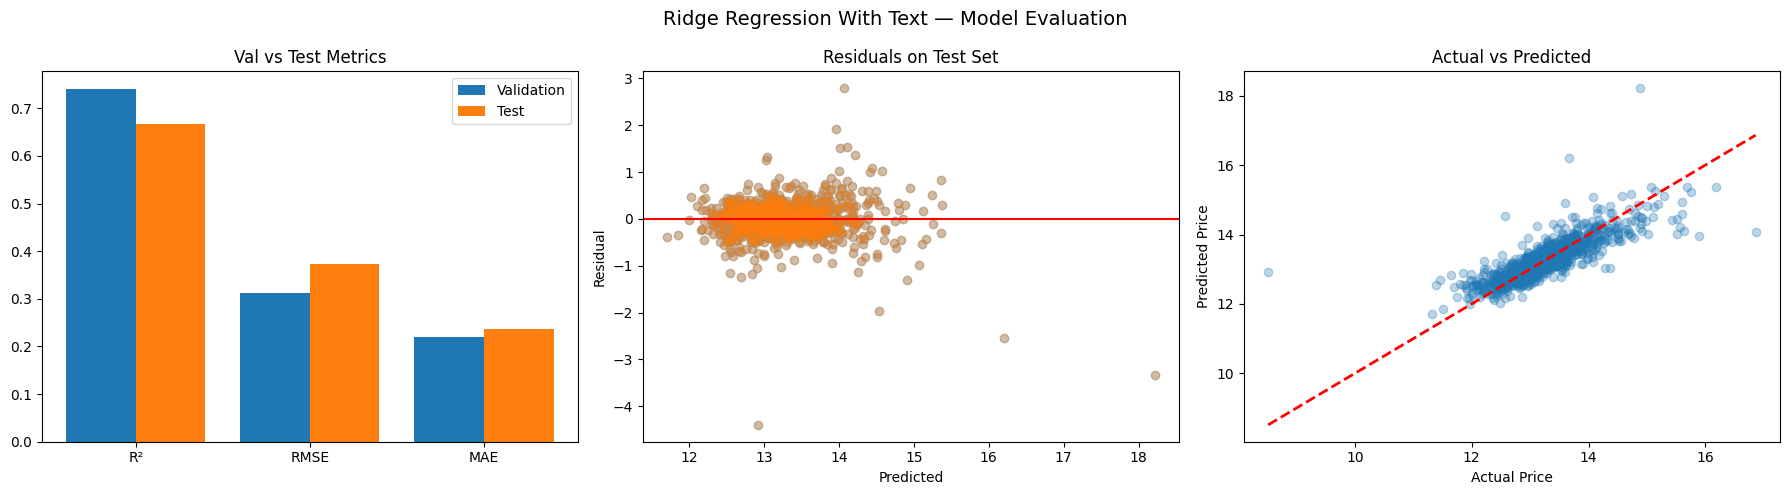

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ridge Regression With Text — Model Evaluation', fontsize=14)

# Plot 1 — Val vs Test metrics
metrics = ['R²', 'RMSE', 'MAE']
val_scores = [r2_score(y_val, y_pred_val),
              np.sqrt(mean_squared_error(y_val, y_pred_val)),
              mean_absolute_error(y_val, y_pred_val)]
test_scores = [r2_score(y_test, y_pred_test),
               np.sqrt(mean_squared_error(y_test, y_pred_test)),
               mean_absolute_error(y_test, y_pred_test)]

x = np.arange(len(metrics))


# Flatten both to 1D arrays before plotting
y_test_flat = np.array(y_test).flatten()
y_val_flat  = np.array(y_val).flatten()
y_pred_test_flat = np.array(y_pred_test).flatten()
y_pred_val_flat  = np.array(y_pred_val).flatten()

# Then use the flat versions throughout
val_scores = [r2_score(y_val_flat, y_pred_val_flat),
              np.sqrt(mean_squared_error(y_val_flat, y_pred_val_flat)),
              mean_absolute_error(y_val_flat, y_pred_val_flat)]

test_scores = [r2_score(y_test_flat, y_pred_test_flat),
               np.sqrt(mean_squared_error(y_test_flat, y_pred_test_flat)),
               mean_absolute_error(y_test_flat, y_pred_test_flat)]

residuals = y_test_flat - y_pred_test_flat

# Rest of your plotting code stays the same, just use the flat versions

axes[0].bar(x - 0.2, val_scores, 0.4, label='Validation')
axes[0].bar(x + 0.2, test_scores, 0.4, label='Test')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_title('Val vs Test Metrics')
axes[0].legend()

# Plot 2 — Residuals
axes[1].scatter(y_pred_test_flat, residuals, alpha=0.3)
axes[1].axhline(0, color='red')
axes[1].set_title('Residuals on Test Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

# Plot 3 — Actual vs Predicted
axes[1].scatter(y_pred_test_flat, residuals, alpha=0.3)
axes[2].scatter(y_test_flat, y_pred_test_flat, alpha=0.3)
axes[2].plot([y_test_flat.min(), y_test_flat.max()],
             [y_test_flat.min(), y_test_flat.max()], 'r--', lw=2)

axes[2].set_title('Actual vs Predicted')
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

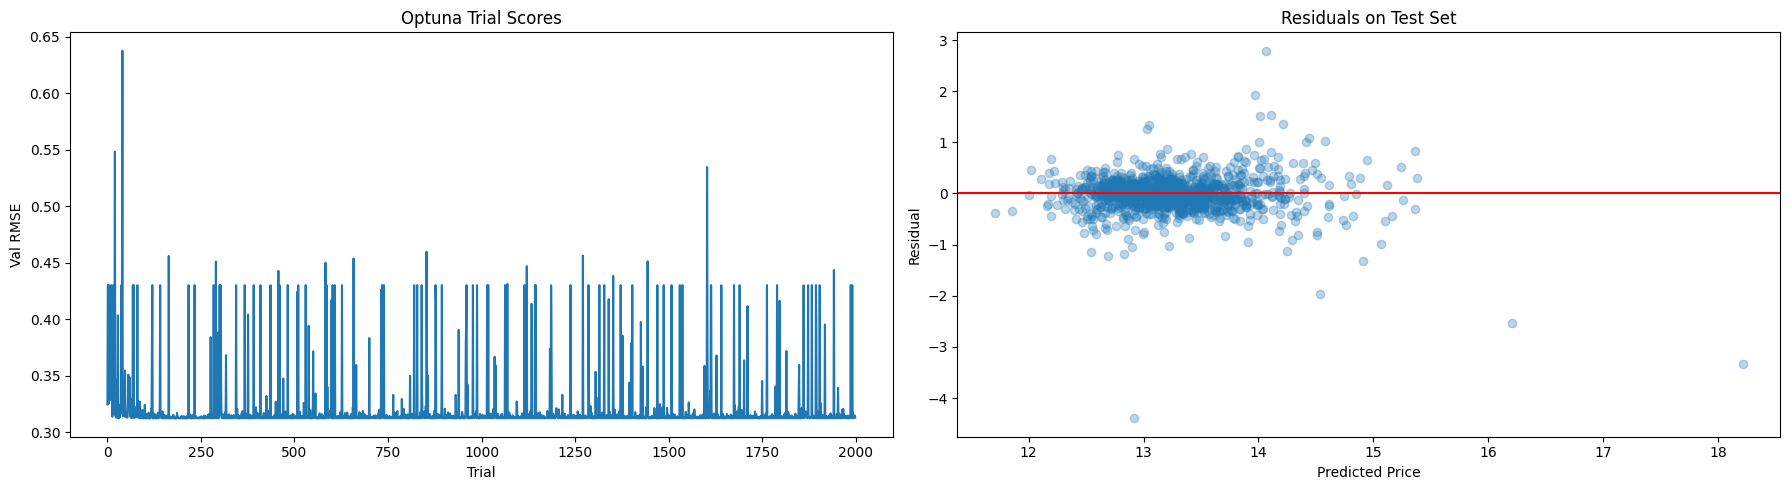

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1 — Optuna trial scores (only if you ran the tuning)
trial_values = [t.value for t in study.trials]
axes[0].plot(trial_values)
axes[0].set_title('Optuna Trial Scores')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Val RMSE')

# Plot 2 — Residuals on test set
residuals = np.array(y_test) - np.array(y_pred_test)
axes[1].scatter(y_pred_test, residuals, alpha=0.3)
axes[1].axhline(0, color='red')
axes[1].set_title('Residuals on Test Set')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')


plt.tight_layout()
plt.show()